Imports and setup

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import DATA_DIR, TARGET_COLUMN, MODEL_DIR

# import numpy as np
import pandas as pd

from src.preprocessing_utils import (
    # chronological_train_test_split,
    create_sequences,
    load_feature_engineered_dataset,
    parse_datetime_index,
    scale_train_test_data,
    split_features_and_target,
)

from src.model_utils import (
    create_lstm_model,
    create_model_comparison_dataframe,
    evaluate_regression_model,
    get_early_stopping_callback,
    plot_actual_vs_predicted,
    plot_training_history,
    save_model_comparison_dataframe,
    train_linear_regression_model,
    train_random_forest_model,
    save_model
)

pd.set_option("display.max_columns", None)

### Model Development and Evaluation

This notebook develops baseline machine learning models and a deep learning model for appliance energy prediction.  
The models are evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Loading the preprocessed datasets 

In [2]:
train_path = DATA_DIR / "train_feature_engineered_data.csv"
test_path = DATA_DIR / "test_feature_engineered_data.csv"

train_df = load_feature_engineered_dataset(train_path)
test_df = load_feature_engineered_dataset(test_path)

train_df = parse_datetime_index(train_df, "date")
test_df = parse_datetime_index(test_df, "date")

In [3]:
# checking dataset shapes
print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (15779, 21)
Testing set shape: (3945, 21)


Split features and targets

In [4]:
x_train_df, y_train_series = split_features_and_target(train_df, TARGET_COLUMN)
x_test_df, y_test_series = split_features_and_target(test_df, TARGET_COLUMN)

print("X_train shape:", x_train_df.shape)
print("X_test shape:", x_test_df.shape)
print("y_train shape:", y_train_series.shape)
print("y_test shape:", y_test_series.shape)

X_train shape: (15779, 20)
X_test shape: (3945, 20)
y_train shape: (15779,)
y_test shape: (3945,)


Scaling features for baseline and LSTM 

In [5]:
x_train_scaled, x_test_scaled, fitted_scaler = scale_train_test_data(
    x_train=x_train_df,
    x_test=x_test_df,
    scaler_type="standard",
)

print("Scaled X_train shape:", x_train_scaled.shape)
print("Scaled X_test shape:", x_test_scaled.shape)

Scaled X_train shape: (15779, 20)
Scaled X_test shape: (3945, 20)


### Training Linear Regression Model

In [6]:
linear_model = train_linear_regression_model(
    x_train=x_train_scaled,
    y_train=y_train_series.to_numpy(),
)

linear_predictions = linear_model.predict(x_test_scaled)

linear_metrics = evaluate_regression_model(
    y_true=y_test_series.to_numpy(),
    y_pred=linear_predictions,
)

linear_metrics

{'MAE': 11.60739674471167, 'RMSE': 18.008791262441505}

In [ ]:
# saving the Linear Regression model
save_model(
    model=linear_model,
    file_name="linear_regression_model.pkl",
)

### Training Random Forest

In [7]:
random_forest_model = train_random_forest_model(
    x_train=x_train_scaled,
    y_train=y_train_series.to_numpy(),
    n_estimators=200,
    random_state=42,
)

random_forest_predictions = random_forest_model.predict(x_test_scaled)

random_forest_metrics = evaluate_regression_model(
    y_true=y_test_series.to_numpy(),
    y_pred=random_forest_predictions,
)

random_forest_metrics

{'MAE': 11.531299112801014, 'RMSE': 17.726541438978803}

In [ ]:
# saving the Random Forest model
save_model(
    model=random_forest_model,
    file_name="random_forest_model_model.pkl",
)

Plotting the baseline model predictions (Linear regressiond and Random forest)

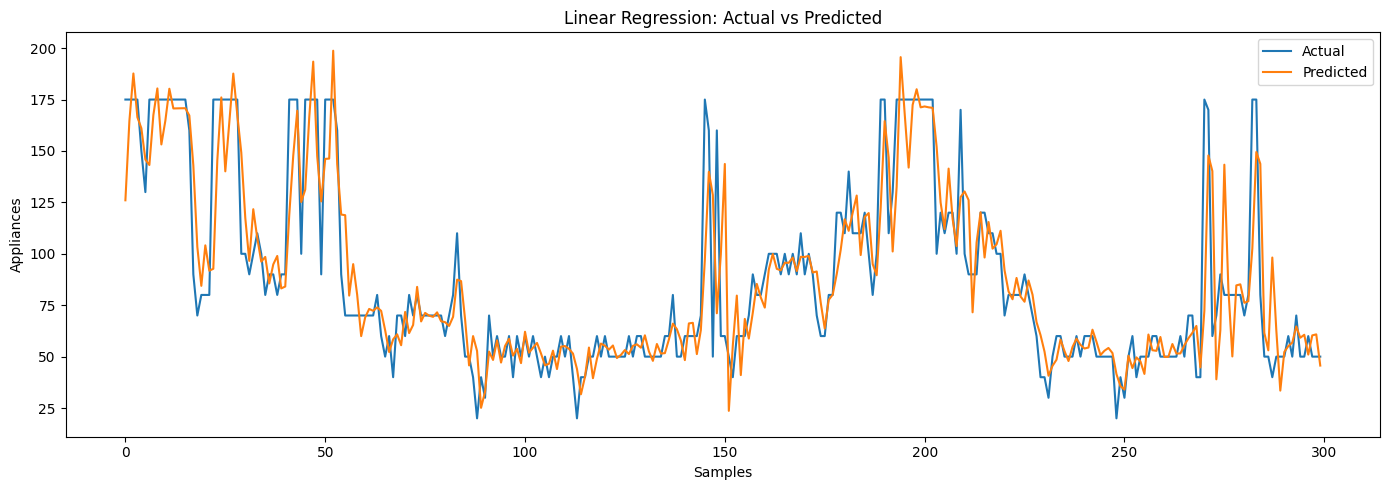

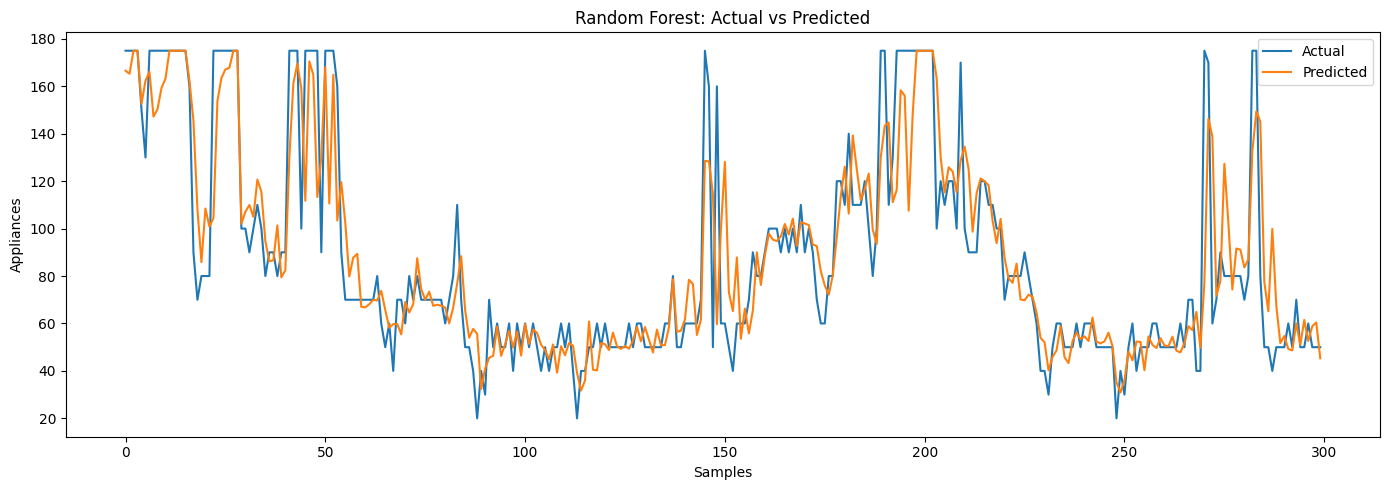

In [8]:
plot_actual_vs_predicted(
    y_true=y_test_series.to_numpy()[:300],
    y_pred=linear_predictions[:300],
    title="Linear Regression: Actual vs Predicted",
)

plot_actual_vs_predicted(
    y_true=y_test_series.to_numpy()[:300],
    y_pred=random_forest_predictions[:300],
    title="Random Forest: Actual vs Predicted",
)

### LSTM model

Creating sequences for LSTM model

In [9]:
sequence_length = 6

x_train_seq, y_train_seq = create_sequences(
    x_data=x_train_scaled,
    y_data=y_train_series.to_numpy(),
    sequence_length=sequence_length,
)

x_test_seq, y_test_seq = create_sequences(
    x_data=x_test_scaled,
    y_data=y_test_series.to_numpy(),
    sequence_length=sequence_length,
)

print("x_train_seq shape:", x_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("x_test_seq shape:", x_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

x_train_seq shape: (15773, 6, 20)
y_train_seq shape: (15773,)
x_test_seq shape: (3939, 6, 20)
y_test_seq shape: (3939,)


Builing the model

In [10]:
lstm_model = create_lstm_model(
    input_shape=(x_train_seq.shape[1], x_train_seq.shape[2]),
    lstm_units=64,
    dropout_rate=0.2,
)

lstm_model.summary()

c:\Users\induw\anaconda3\envs\energy_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,873 (93.25 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

Training the model

In [11]:
early_stopping = get_early_stopping_callback(patience=5)

history = lstm_model.fit(
    x_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4673.3154 - mae: 53.2570 - val_loss: 751.2645 - val_mae: 17.8789
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 926.2195 - mae: 21.1901 - val_loss: 645.8716 - val_mae: 17.1724
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 840.7390 - mae: 19.6604 - val_loss: 618.2646 - val_mae: 16.9748
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 811.5882 - mae: 19.1799 - val_loss: 599.5955 - val_mae: 16.0840
Epoch 5/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 755.0288 - mae: 18.4954 - val_loss: 575.7520 - val_mae: 15.9670
Epoch 6/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 757.1905 - mae: 18.5855 - val_loss: 562.9739 - val_mae: 15.9269
Epoch 7/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 702.8645 - mae: 17.8504 - val_loss: 545.2890 - val_mae: 16.1108
Epoch 8/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 687.5059 - mae: 17.7900 - val_loss: 529.5676 - val_mae: 15.5469
Epoch 9

In [ ]:
# saving the LSTM model
save_model(
    model=lstm_model,
    file_name="lstm_model.pkl",
)

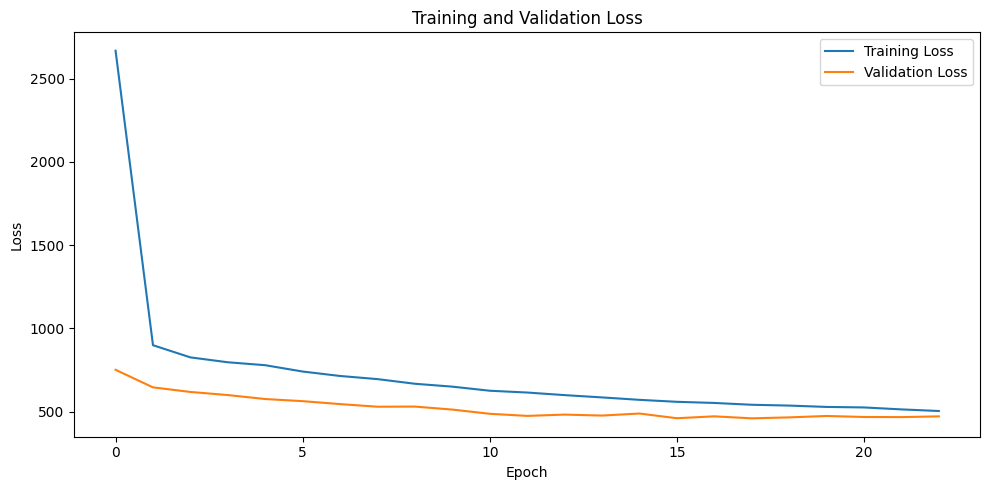

In [12]:
# plotting training history
plot_training_history(history)

Evaluating the LSTM model

In [13]:
lstm_predictions = lstm_model.predict(x_test_seq).flatten()

lstm_metrics = evaluate_regression_model(
    y_true=y_test_seq,
    y_pred=lstm_predictions,
)

lstm_metrics

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


{'MAE': 14.925453186035156, 'RMSE': 22.715578301214208}

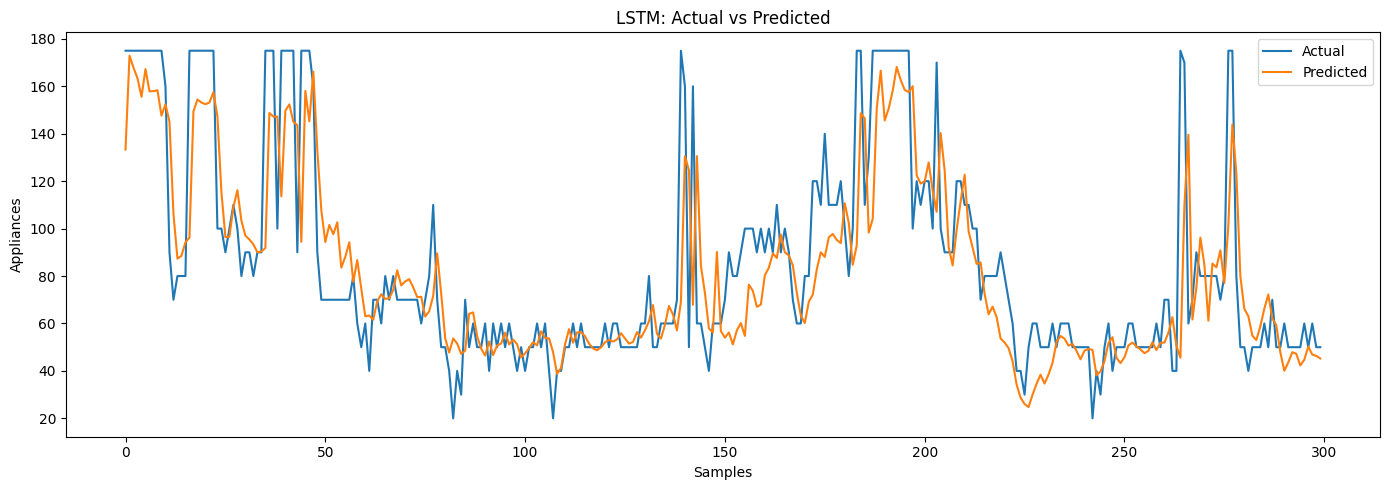

In [14]:
# plotting LSTM model predictions
plot_actual_vs_predicted(
    y_true=y_test_seq[:300],
    y_pred=lstm_predictions[:300],
    title="LSTM: Actual vs Predicted",
)

### Model Comparison 

In [15]:
comparison_df = create_model_comparison_dataframe(
    linear_metrics=linear_metrics,
    random_forest_metrics=random_forest_metrics,
    lstm_metrics=lstm_metrics,
)

comparison_df

,model,MAE,RMSE
0,Linear Regression,11.607397,18.008791
1,Random Forest,11.531299,17.726541
2,LSTM,14.925453,22.715578


In [16]:
# saving comparison table
save_model_comparison_dataframe(
    comparison_df=comparison_df,
    file_name="model_comparison_results.csv"
)